In [49]:
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')
sns.set_theme(style='whitegrid')

### data loading

In [50]:
df_arrests: pd.DataFrame = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/arrests_cleaned.parquet')
df_detainers: pd.DataFrame  = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/detainers_cleaned.parquet')
df_detentions: pd.DataFrame = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/detention_stays_cleaned.parquet')

print(f"    - {len(df_arrests):,} arrests")
print(f"    - {len(df_detainers):,} detainers")
print(f"    - {len(df_detentions):,} detentions")

    - 362,202 arrests
    - 329,483 detainers
    - 671,750 detentions


In [ ]:
### data overview

### data integrity concern analysis

In [51]:
# MSC SENTENCE ANALYSIS
df_detainers['msc_sentence_days_total'].describe().round(0)


count     78215.0
mean       1184.0
std        3923.0
min           1.0
25%          75.0
50%         365.0
75%        1126.0
max      364635.0
Name: msc_sentence_days_total, dtype: float64

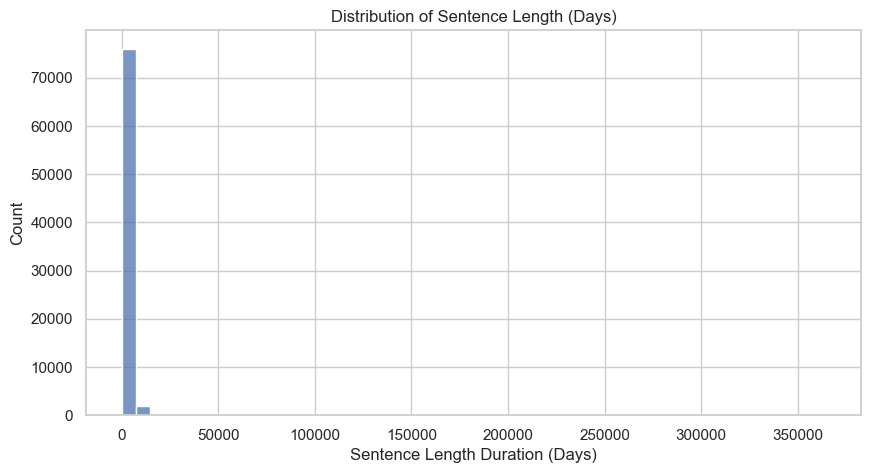

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_detainers,
    x='msc_sentence_days_total',
    bins=50,
    ax=ax
)

ax.set_title('Distribution of Sentence Length (Days)')
ax.set_xlabel('Sentence Length Duration (Days)')
ax.set_ylabel('Count')

plt.tight_layout
plt.show()

# the plot that is returned is skewed heavily by the massively long sentences in the data

In [53]:
# Defining a new category/column to flag virtual life sentences per The Sentencing Project's definition
# www.sentencingproject.org

virtual_life_days: int = 18250 # 50 years x 365 days

df_detainers['virtual_life_sentence'] = (df_detainers['msc_sentence_days_total'] >= virtual_life_days)

total_sentenced: int = df_detainers['msc_sentence_days_total'].notna().sum()
virtual_life_count: int = df_detainers['virtual_life_sentence'].sum()

print(f'Total records with sentence data:    {total_sentenced}')
print(f'Virtual life sentences flagged:    {virtual_life_count:,}')
print(f'Percentage of sentenced records:    {virtual_life_count / total_sentenced * 100:.2f}%')

Total records with sentence data:    78215
Virtual life sentences flagged:    183
Percentage of sentenced records:    0.23%


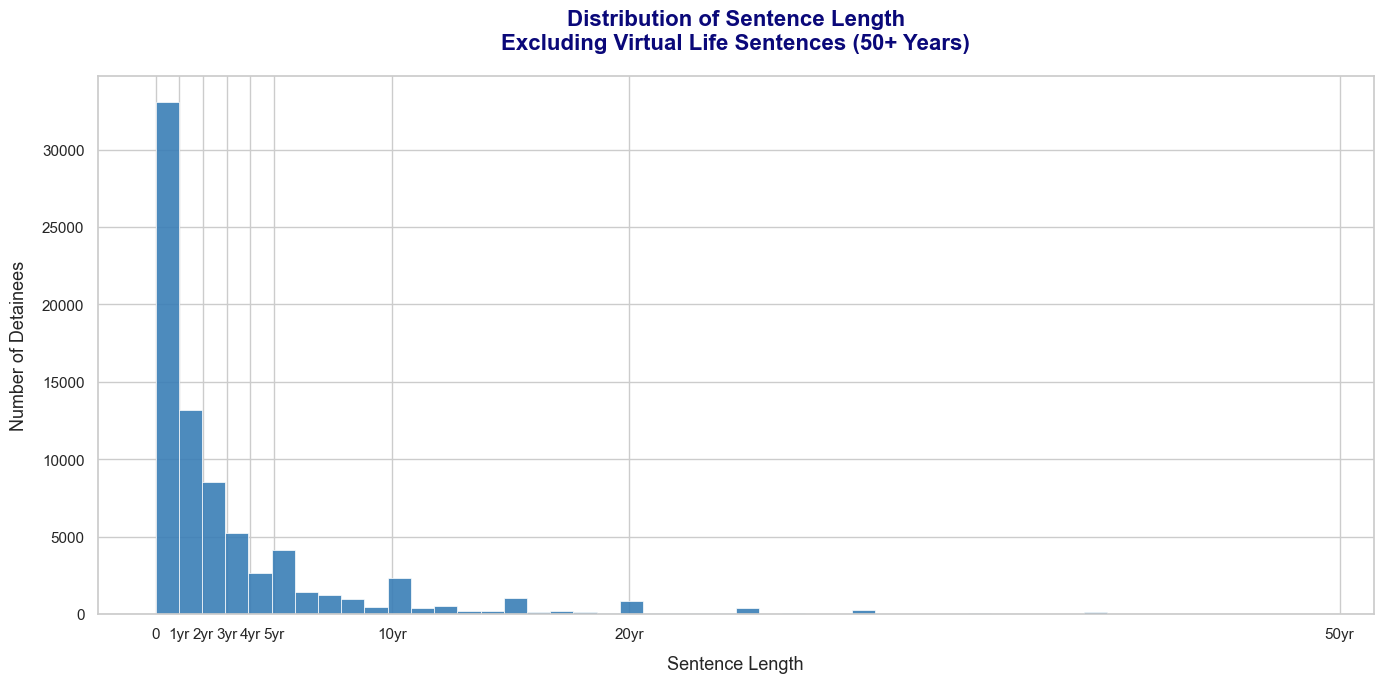

In [58]:
fig, ax = plt.subplots(figsize=(14, 7))

plot_data = df_detainers[df_detainers['virtual_life_sentence'] == False]

sns.histplot(
    data=plot_data,
    x='msc_sentence_days_total',
    bins=50,
    ax=ax,
    color='#3a7eb6',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.9
)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.set_title(
    'Distribution of Sentence Length\nExcluding Virtual Life Sentences (50+ Years)',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#0a0879'
)
ax.set_xlabel('Sentence Length', fontsize=13, labelpad=10)
ax.set_ylabel('Number of Detainees', fontsize=13, labelpad=10)

ax.set_xticks([0, 365, 730, 1095, 1460, 1825, 3650, 7300, 18250])
ax.set_xticklabels(
    ['0', '1yr', '2yr', '3yr', '4yr', '5yr', '10yr', '20yr', '50yr'],
    fontsize=11
)

plt.tight_layout()
plt.show()